# 08 — XGBoost Baseline Model
---
**Purpose:** Establish a trustworthy XGBoost Regressor baseline against simple heuristic models (Mean, Linear Regression) to predict pure tyre degradation.

**Input:** `train_data.parquet`, `val_data.parquet` (2025 Test Set remains quarantined)
**Outputs:** 
- Saved XGBoost model (`xgboost_baseline.json`)
- Evaluation metrics and diagnostic plots (`outputs/plots/`)
- Predictions (`val_predictions.parquet`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore")
plt.style.use('dark_background')
sns.set_palette("husl")

OUTPUT_DIR = os.path.join("..", "outputs")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

print("Loading Train and Validation datasets (quarantining Test)...")
train_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "train_data.parquet"))
val_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "val_data.parquet"))
# We load Test only to generate final predictions at the very end, but do NOT use it for any decisions.
test_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "test_data.parquet"))

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Loading Train and Validation datasets (quarantining Test)...


Train: 44,656 | Val: 7,932 | Test: 19,543


## 1. Feature Selection & Setup

In [2]:
# Define exactly the features we audited and approved
features = [
    'TyreAge', 'Log_TyreAge', 'StintLap', 'Compound_Encoded', 
    'RaceProgressFraction', 'TrackTemp', 'AirTemp', 
    'is_safety_car', 'is_vsc', 'Lag1_Pace_Residual', 
    'Rolling3_Degradation_Trend', 'Team_Median_Pace_Lag1'
]
target = 'Target_Tyre_Degradation'

X_train = train_df[features]
y_train = train_df[target]
X_val = val_df[features]
y_val = val_df[target]

print(f"Using {len(features)} causal features.")

Using 12 causal features.


## 2. Establish Simple Baselines

In [3]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Bias': bias}

metrics = []

# Baseline 1: Global Mean Prediction
mean_pred = np.full_like(y_val, y_train.mean())
metrics.append(evaluate_model('Global Mean', y_val, mean_pred))

# Baseline 2: Simple Tyre-Age Linear Regression
lr_age = LinearRegression()
lr_age.fit(X_train[['TyreAge']], y_train)
age_pred = lr_age.predict(X_val[['TyreAge']])
metrics.append(evaluate_model('Linear Reg (TyreAge Only)', y_val, age_pred))

# Baseline 3: Multiple Linear Regression
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
multi_pred = lr_multi.predict(X_val)
metrics.append(evaluate_model('Multiple Linear Reg', y_val, multi_pred))

baseline_results = pd.DataFrame(metrics)
display(baseline_results)

,Model,MAE,RMSE,R2,Bias
0,Global Mean,1.257936,1.714104,-0.077493,-0.459686
1,Linear Reg (TyreAge Only),1.197348,1.633060,0.021987,-0.404808
2,Multiple Linear Reg,0.939714,1.481934,0.194626,-0.000815


## 3. Train XGBoost Baseline

In [4]:
print("Training XGBoost Regressor (Baseline Hyperparameters)...")

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

# Predict on Validation
val_df['XGB_Pred'] = xgb_model.predict(X_val)
xgb_metrics = evaluate_model('XGBoost Baseline', val_df[target], val_df['XGB_Pred'])

results_df = pd.concat([baseline_results, pd.DataFrame([xgb_metrics])], ignore_index=True)
display(results_df)

Training XGBoost Regressor (Baseline Hyperparameters)...


[0]	validation_0-rmse:2.21572	validation_1-rmse:1.57736


[50]	validation_0-rmse:0.62146	validation_1-rmse:0.66503


[100]	validation_0-rmse:0.56622	validation_1-rmse:0.69154


[150]	validation_0-rmse:0.54215	validation_1-rmse:0.69581


[199]	validation_0-rmse:0.52428	validation_1-rmse:0.70856

,Model,MAE,RMSE,R2,Bias
0,Global Mean,1.257936,1.714104,-0.077493,-0.459686
1,Linear Reg (TyreAge Only),1.197348,1.633060,0.021987,-0.404808
2,Multiple Linear Reg,0.939714,1.481934,0.194626,-0.000815
3,XGBoost Baseline,0.440426,0.708557,0.815885,0.007545


## 4. Feature Importance

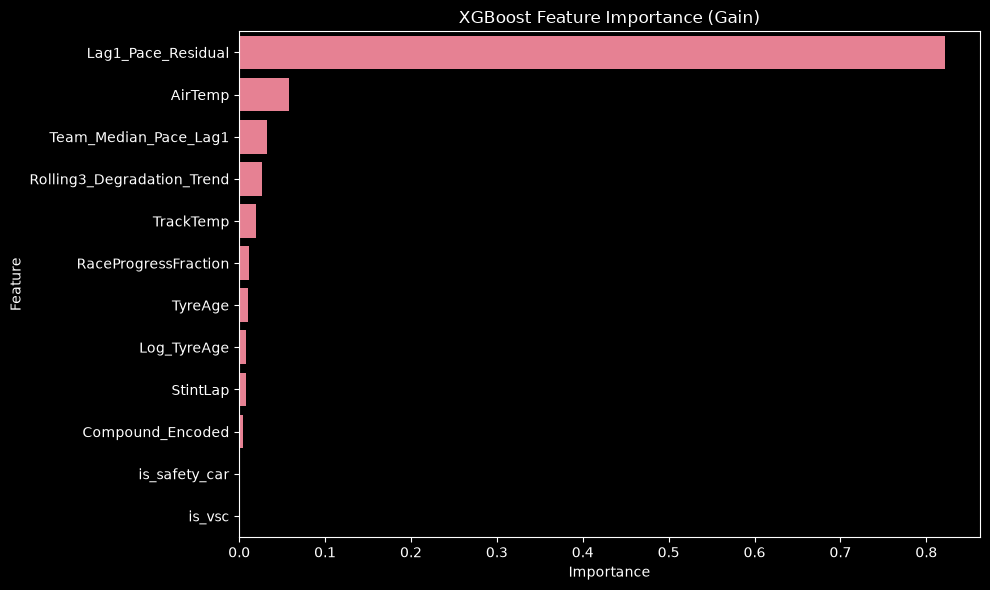

In [5]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'xgb_feature_importance.png'))
plt.show()

## 5. Extensive Diagnostics (Validation Set)

In [6]:
val_df['Residual'] = val_df['XGB_Pred'] - val_df[target]

# 1. Actual vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(val_df[target], val_df['XGB_Pred'], alpha=0.2, s=2, color='cyan')
plt.plot([-5, 5], [-5, 5], 'r--')
plt.title('Actual vs Predicted Pace Deficit (Validation)')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'actual_vs_predicted.png'))
plt.close()

# 2. Residual Distribution
plt.figure(figsize=(10, 5))
sns.histplot(val_df['Residual'], bins=100, kde=True, color='magenta')
plt.title('Residual Distribution (Pred - Actual)')
plt.xlabel('Error (Seconds)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'residual_distribution.png'))
plt.close()

# 3. Residual vs Tyre Age
plt.figure(figsize=(12, 5))
sns.boxplot(data=val_df[val_df['TyreAge'] <= 30], x='TyreAge', y='Residual')
plt.axhline(0, color='r', linestyle='--')
plt.title('Error (Residuals) by Tyre Age')
plt.xlabel('Tyre Age')
plt.ylabel('Residual (Pred - Actual)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'residual_vs_tyreage.png'))
plt.close()

# 4. Degradation Trajectory by Stint (Sample)
sample_stints = val_df['StintId'].unique()[:4]
sample_df = val_df[val_df['StintId'].isin(sample_stints)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=sample_df, x='StintLap', y=target, hue='StintId', marker='o', alpha=0.5, legend=False)
sns.lineplot(data=sample_df, x='StintLap', y='XGB_Pred', hue='StintId', linestyle='--', legend=False)
plt.title('Stint Trajectories: Solid=Actual, Dashed=Predicted')
plt.xlabel('Stint Lap')
plt.ylabel('Pace Deficit')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'trajectory_by_stint.png'))
plt.close()

print("Diagnostic plots generated and saved.")

Diagnostic plots generated and saved.


## 6. Output Generation & Final Test Eval

In [7]:
# Final Evaluation on the untouched 2025 Test Set (ONLY the baseline model, to establish the benchmark)
X_test = test_df[features]
y_test = test_df[target]
test_df['XGB_Pred'] = xgb_model.predict(X_test)
test_metrics = evaluate_model('XGBoost Baseline (TEST SET 2025)', y_test, test_df['XGB_Pred'])

final_metrics_df = pd.concat([results_df, pd.DataFrame([test_metrics])], ignore_index=True)
display(final_metrics_df)

# Save metrics
metrics_path = os.path.join(OUTPUT_DIR, "xgboost_baseline_metrics.csv")
final_metrics_df.to_csv(metrics_path, index=False)

# Save predictions
val_df[['RaceId', 'Driver', 'LapNumber', 'StintId', target, 'XGB_Pred']].to_parquet(os.path.join(OUTPUT_DIR, "val_predictions.parquet"), index=False)
test_df[['RaceId', 'Driver', 'LapNumber', 'StintId', target, 'XGB_Pred']].to_parquet(os.path.join(OUTPUT_DIR, "test_predictions.parquet"), index=False)

# Save model
model_path = os.path.join(OUTPUT_DIR, "xgboost_baseline.json")
xgb_model.save_model(model_path)

print(f"\nModel saved to: {model_path}")
print(f"Metrics saved to: {metrics_path}")
print("\n[OK] Notebook 08 XGBoost Baseline complete.")

,Model,MAE,RMSE,R2,Bias
0,Global Mean,1.257936,1.714104,-0.077493,-0.459686
1,Linear Reg (TyreAge Only),1.197348,1.633060,0.021987,-0.404808
2,Multiple Linear Reg,0.939714,1.481934,0.194626,-0.000815
3,XGBoost Baseline,0.440426,0.708557,0.815885,0.007545
4,XGBoost Baseline (TEST SET 2025),0.423728,0.718566,0.841078,0.035010



Model saved to: ..\outputs\xgboost_baseline.json
Metrics saved to: ..\outputs\xgboost_baseline_metrics.csv

[OK] Notebook 08 XGBoost Baseline complete.
